In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial import distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch.nn.functional as F

In [2]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [99]:
class brain(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_clusters, output_dim):
        super().__init__()
        self.rnn = nn.RNN(input_dim, hidden_dim, nonlinearity='relu', batch_first=True)
        self.centroids = nn.Parameter(torch.randn(num_clusters, hidden_dim))  # cluster centers
        
        # NEW: output layer takes combined input from h_seq and clustered_h
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None):
        # x: (batch, seq_len, input_dim)
        h_seq, h = self.rnn(x, h0)  # h_seq: (B, S, H)

        # # Normalize hidden states and centroids
        # h_norm = F.normalize(h_seq, dim=-1)         # (B, S, H)
        # c_norm = F.normalize(self.centroids, dim=-1)  # (C, H)

        # # Compute soft assignment: cosine similarity (B, S, C)
        # sim = torch.einsum("bsh,ch->bsc", h_norm, c_norm)
        # soft_assign = F.softmax(sim / 0.05, dim=-1)  # lower temp → sharper assignment

        # # Get soft-clustered representation (B, S, H)
        # clustered_h = torch.einsum("bsc,ch->bsh", soft_assign, self.centroids)

        # # Concatenate h_seq and clustered_h: (B, S, 2H)
        # combined = torch.cat([h_seq, clustered_h], dim=-1)

        # Final prediction
        logits = self.output_layer(h_seq)  # (B, S, output_dim)
        return logits, _, h

In [100]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [101]:
### initial training ###
total_samples = 50000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 40
hidden_sleep_size = 10
sleep_output_size = 5
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 1e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)#gen_seq(total_samples) #

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = brain(input_size, hidden_wake_size, num_clusters=10, output_dim=len(tokens))

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, c, hidden = network1(X)
    else:
        predicted_y, c, hidden = network1(X, mem)
    
    # print(predicted_y.shape, y.shape)
    loss = criterion(predicted_y[0], y)
    #loss_repel = 1e-1 * network1.repulsion_loss(margin=1.0)
    
    loss = loss #+ loss_repel
    
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')


Iter : 1001, loss: 1.8752, accuracy: 0.1590
Iter : 2001, loss: 1.9134, accuracy: 0.2510
Iter : 3001, loss: 2.0714, accuracy: 0.2500
Iter : 4001, loss: 1.9694, accuracy: 0.2500
Iter : 5001, loss: 1.9883, accuracy: 0.2500
Iter : 6001, loss: 1.9918, accuracy: 0.2500
Iter : 7001, loss: 2.0116, accuracy: 0.2530
Iter : 8001, loss: 1.8165, accuracy: 0.2600
Iter : 9001, loss: 1.9839, accuracy: 0.2730
Iter : 10001, loss: 2.1614, accuracy: 0.3010
Iter : 11001, loss: 1.7042, accuracy: 0.3610
Iter : 12001, loss: 1.5343, accuracy: 0.3860
Iter : 13001, loss: 1.8567, accuracy: 0.4500
Iter : 14001, loss: 1.5335, accuracy: 0.5010
Iter : 15001, loss: 1.7966, accuracy: 0.5320
Iter : 16001, loss: 2.2013, accuracy: 0.5500
Iter : 17001, loss: 1.4645, accuracy: 0.6030
Iter : 18001, loss: 2.5859, accuracy: 0.6240
Iter : 19001, loss: 1.6536, accuracy: 0.6420
Iter : 20001, loss: 1.9740, accuracy: 0.6530
Iter : 21001, loss: 1.3189, accuracy: 0.6570
Iter : 22001, loss: 1.6506, accuracy: 0.6610
Iter : 23001, loss:

In [92]:
c

tensor([[[4.5497e-01, 4.4290e-03, 3.2358e-01, 2.0173e-01, 9.8146e-05,
          1.7177e-03, 7.4765e-05, 3.1350e-03, 9.8053e-03, 4.5383e-04]]],
       grad_fn=<SoftmaxBackward0>)

In [103]:
chosen = []
hidden_states = []

data = get_sequence(100, n_community, n_members, train_percent=1.0)#gen_seq(total_samples) #

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, c, hidden = network1(X)
    else:
        predicted_y, c, hidden = network1(X, mem)
    
    # print(predicted_y.shape, y.shape)
    loss = criterion(predicted_y[0], y)
    #loss_repel = 1e-1 * network1.repulsion_loss(margin=1.0)
    
    loss = loss #+ loss_repel
    
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')
        # chosen.append(c.argmax())
        hidden_states.append(hidden[0][0])

Iter : 50001, loss: 6.0724, accuracy: 0.6660


In [104]:
from scipy.spatial.distance import cosine
from sklearn.manifold import MDS, TSNE

D = np.zeros((len(hidden_states), len(hidden_states)), dtype=float)

for ii in range(len(hidden_states)):
    for jj in range(len(hidden_states)):
        D[ii,jj] = cosine(hidden_states[ii].detach().numpy(), hidden_states[jj].detach().numpy()) 

# hidden_states = np.array(hidden_states)
embedding = MDS(n_components=2, dissimilarity='precomputed', random_state=101)#TSNE(n_components=2, perplexity=30, random_state=42)#
X_transformed = embedding.fit_transform(D)

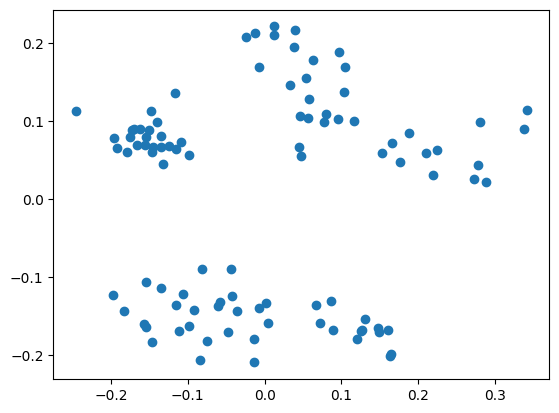

In [105]:
plt.scatter(X_transformed[:,0], X_transformed[:,1])

In [96]:
from scipy.spatial.distance import cosine
from sklearn.manifold import MDS, TSNE

D = np.zeros((len(chosen), len(chosen)), dtype=float)

for ii in range(len(chosen)):
    for jj in range(len(chosen)):
        D[ii,jj] = cosine(chosen[ii].detach().numpy(), chosen[jj].detach().numpy()) 

# hidden_states = np.array(hidden_states)
embedding = MDS(n_components=2, dissimilarity='precomputed', random_state=101)#TSNE(n_components=2, perplexity=30, random_state=42)#
X_transformed = embedding.fit_transform(D)

ValueError: Input vector should be 1-D.

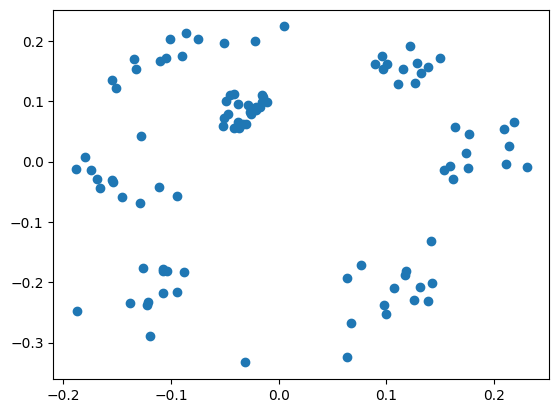

In [97]:
plt.scatter(X_transformed[:,0], X_transformed[:,1])

In [98]:
chosen

[tensor(2),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(0),
 tensor(0),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 tensor(2),
 ten